# PyBTI — borehole temperature workflow
**Synthetic case A · Python 3.12**

Read input data → generate the mesh → assign material properties → build the ground
surface temperature history (GSTH) → generate initial conditions → optionally run a
separate forward simulation → Tikhonov inversion → result plots and saved results.

All modelling steps call the existing Python modules and pass MATLAB-style
dictionaries. The mesh is the first **generated model input**; raw data are read
first so their depths can be included without interpolating temperatures.

**Start here:** activate the `BTI` Conda environment, open this notebook with its
kernel, and run all cells from the top. Change the **initialisation dictionary in
step 1** to choose `"equilibrium"` or `"periodic"`. Restart and run all cells after
changing parameters. Tikhonov inversion runs in steps 10–13 using SITE_Tikh.m settings.
MCMC and its result plots remain a later task.

Provenance: Codex (OpenAI), 2026-09-22. Uses the existing MATLAB translations;
validated on synthetic cases, not against MATLAB output or measured boreholes.


In [1]:
from pathlib import Path
import sys
import json
import platform
from html import escape

# Locate the repository from either its root or a subfolder.
ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "workflow.py").is_file() and (p / "examples" / "A").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Start Jupyter in the PyBTI repository or one of its subfolders.")
if sys.version_info[:2] != (3, 12):
    raise RuntimeError("Select the Python 3.12 (BTI) kernel, then restart this notebook.")
sys.path.insert(0, str(ROOT))

%matplotlib inline
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from prep import read_data, prepare_site
from workflow import build_mesh, run_forward, plot_forward
from init import YEAR2SEC, build_gsth, build_initial

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | "
      f"SciPy {scipy.__version__} | Matplotlib {matplotlib.__version__}")
print(f"Project: {ROOT}")


Python 3.12.14 | NumPy 1.26.4 | SciPy 1.14.1 | Matplotlib 3.10.9
Project: C:\Users\Mottaghy\Documents\GitHub\PyBTI


## 1. Choose initialisation and edit the parameter dictionaries
- **`equilibrium`**: calculate a steady-state profile from `GST0`, material
  properties and basal heat flow, then run the prescribed transient history.
- **`periodic`**: start from that equilibrium and repeat the history
  `initial_iter` times. Each cycle starts at the previous cycle's final profile.
  By default, stop there; `Tinit` is the last cycle's result.
- **`initial_tol`**: `None` runs all cycles; a positive value stops when the
  maximum absolute successive-profile change is at most that value in K.

The notebook uses **periodic** mode by default. It does not use the command-line
overrides in `run_forward.py`. No data residuals are calculated during initialisation.


In [2]:
initpar = dict(
    init_type="periodic",  # CHANGE HERE: "equilibrium" or "periodic"
    GST0=6.0,             # absolute surface temperature of the starting equilibrium [°C]
    initial_iter=30,
    initial_tol=None,     # optional maximum-profile-change tolerance [K], e.g. 1e-3
    verbose=False,
)

# A separate forward simulation is automatic for equilibrium mode.
# In periodic mode, True deliberately applies the GST history ONE MORE TIME.
forward_options = dict(run_after_periodic=False, show_residuals=True)

DATA = ROOT / "examples" / "A"
OUTPUT = DATA / "output" / "notebook" / initpar["init_type"]
datapar = dict(
    file=DATA / "DataBallingA.csv", zcol=0, Tcol=3, Terr=0.05,
    depth_range=(10.0, 2000.0), synthetic=True,
)
# Optional artificial noise; only allowed for synthetic data:
# datapar["noise"] = dict(kind="gaussian", length=150.0, seed=0)

meshpar = dict(
    name="SYNA", min_depth=5000.0, depth=dict(zend=5000.0),
    time=dict(tstart=110000 * YEAR2SEC, tend=30 * YEAR2SEC, nt=401),
    time_nodes=[-70000 * YEAR2SEC, -10000 * YEAR2SEC],
)
site_inputs = dict(
    name="SYNA", props="syn",
    k=2.3253, r=1000.0, c=2500.0, h=0.0001e-6, p=0.0001,
    kA=0.0, kB=0.0, qb=-0.069759,
)
fwdpar = dict(theta=1.0, maxitnl=4, tolnl=1e-5, freeze=1)
gstpar = dict(
    file=DATA / "GSTHBallingA.csv", form="steps",
    time_unit="yr", time_convention="before_reference", prehistory=6.0,
)
print(f"Initialisation: {initpar['init_type']}; output folder: {OUTPUT}")


Initialisation: periodic; output folder: C:\Users\Mottaghy\Documents\GitHub\PyBTI\examples\A\output\notebook\periodic


## 2. Read and inspect the data
In `DataBallingA.csv`, zero-based columns are depth (0), climate anomaly (1),
background profile (2), and total synthetic temperature (3). The full file extends
to 7,000 m; this example retains input rows between 10 and 2,000 m for later
forward/data comparisons. Their temperatures are not resampled onto the mesh.

Uncertainty `Terr=0.05 K` does not add noise by itself. Noise is added only when
the explicit `datapar["noise"]` setting is present. The input data are shown here
for inspection; they are not a convergence target for repeated initialisation.


File: DataBallingA.csv
Raw rows: 141; retained rows: 40
First five selected rows: depth [m], temperature [°C], uncertainty [K]
[[5.0000e+01 7.1760e+00 5.0000e-02]
 [1.0000e+02 8.3550e+00 5.0000e-02]
 [1.5000e+02 9.5380e+00 5.0000e-02]
 [2.0000e+02 1.0727e+01 5.0000e-02]
 [2.5000e+02 1.1924e+01 5.0000e-02]]


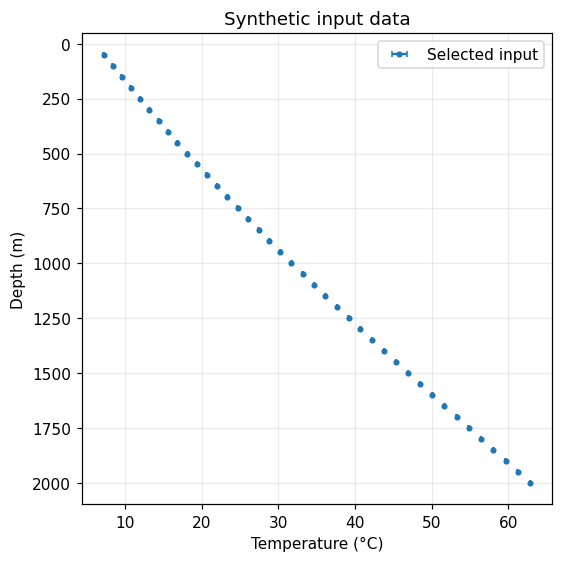

In [3]:
observations = read_data(datapar)
preview = np.column_stack((
    observations["zobs"], observations["Tobs"], observations["Terr"]
))
print(f"File: {observations['file'].name}")
print(f"Raw rows: {len(observations['raw'])}; retained rows: {len(preview)}")
print("First five selected rows: depth [m], temperature [°C], uncertainty [K]")
print(preview[:5])

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
ax.errorbar(observations["Tobs"], observations["zobs"],
            xerr=observations["Terr"], fmt=".", capsize=2, label="Selected input")
ax.set(xlabel="Temperature (°C)", ylabel="Depth (m)", title="Synthetic input data")
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 3. Generate the spatial and temporal meshes
The model extends to **at least 5,000 m**, including when a smaller `zend` is
entered. Observation depths are inserted as nodes; known GST transitions are
inserted as time nodes. Material properties are assigned after this step.

Internal time is in seconds relative to the reference, increasing from negative
values to zero. The displayed age is `-t / YEAR2SEC`. It is not a calendar year.


Depth: 5000 m; 292 depth nodes; 403 time nodes
Time span: 110,000 years before reference to 0


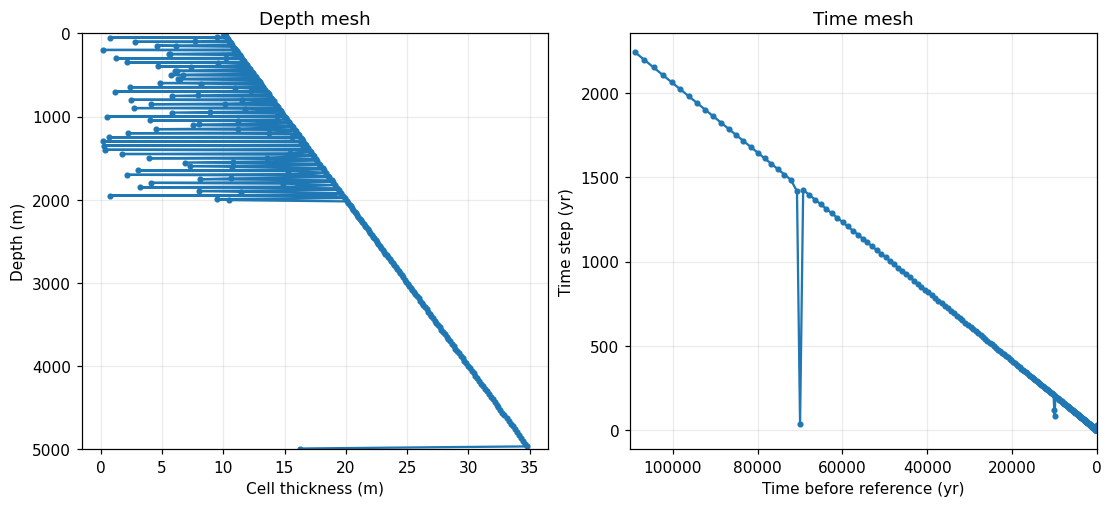

In [4]:
mesh_settings = dict(meshpar)
mesh_settings["min_depth"] = max(5000.0, meshpar.get("min_depth", 0.0))
mesh = build_mesh(mesh_settings, observations)
assert mesh["z"][-1] >= 5000.0
print(f"Depth: {mesh['z'][-1]:.0f} m; {mesh['nz']} depth nodes; "
      f"{mesh['nt']} time nodes")
print(f"Time span: {-mesh['t'][0] / YEAR2SEC:,.0f} years before reference to 0")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
axes[0].plot(mesh["dz"], mesh["zm"], ".-")
axes[0].set(xlabel="Cell thickness (m)", ylabel="Depth (m)",
            title="Depth mesh", ylim=(mesh["z"][-1], 0))
axes[1].plot(-mesh["tm"] / YEAR2SEC, mesh["dt"] / YEAR2SEC, ".-")
axes[1].set(xlabel="Time before reference (yr)", ylabel="Time step (yr)",
            title="Time mesh", xlim=(-mesh["t"][0] / YEAR2SEC, 0))
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()


## 4. Assign material properties and prepare SitePar
Depth increases downward. Basal heat flow `qb` follows the translated solver's
sign convention: normal upward terrestrial heat flow is **negative**.
`props="syn"` selects the synthetic material laws.

Inputs can be scalar or per-unit arrays with an explicit, zero-based `ip`
mapping. Here the synthetic properties are uniform. The resulting `sitepar`
also contains observation indices for optional later comparisons.


In [5]:
sitepar = prepare_site(site_inputs, mesh, observations)
property_rows = [
    ("Thermal conductivity", "k", "W/(m K)"),
    ("Density", "r", "kg/m³"),
    ("Specific heat capacity", "c", "J/(kg K)"),
    ("Heat production", "h", "W/m³"),
    ("Porosity", "p", "fraction"),
]
rows = "".join(
    f"<tr><td>{escape(label)}</td><td>{sitepar[key].min():.6g}</td>"
    f"<td>{sitepar[key].max():.6g}</td><td>{escape(unit)}</td></tr>"
    for label, key, unit in property_rows
)
display(HTML("<table><tr><th>Property</th><th>Minimum</th><th>Maximum</th>"
             "<th>Unit</th></tr>" + rows + "</table>"))
print(f"Basal heat flow: {sitepar['qb']:.6g} W/m²")
print(f"All {len(sitepar['id'])} retained data depths map to mesh nodes.")


Property,Minimum,Maximum,Unit
Thermal conductivity,2.3253,2.3253,W/(m K)
Density,1000,1000,kg/m³
Specific heat capacity,2500,2500,J/(kg K)
Heat production,1e-10,1e-10,W/m³
Porosity,0.0001,0.0001,fraction


Basal heat flow: -0.069759 W/m²
All 40 retained data depths map to mesh nodes.


## 5. Build and inspect the paleoclimate forcing
The two-column GST file supplies age before reference (yr) and absolute surface
temperature (°C). Step values apply from their transition onward. The explicit
`prehistory=6 °C` covers the model period before the oldest supplied transition.

The plot below shows the actual boundary values used on solver intervals:
`GST[it[j]]` on `t[j] … t[j+1]`. The final node pointer is unused by the solver.


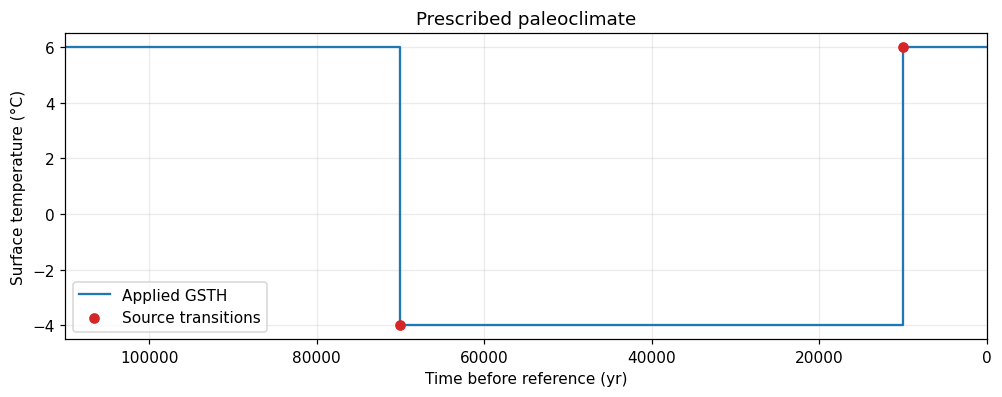

In [6]:
forcing = build_gsth(mesh, gstpar)
applied_gst = forcing["GST"][forcing["it"][:-1]]
age = -mesh["t"] / YEAR2SEC

fig, ax = plt.subplots(figsize=(9, 3.5), layout="constrained")
ax.step(age, np.r_[applied_gst, applied_gst[-1]], where="post", label="Applied GSTH")
ax.scatter(-forcing["t_history"] / YEAR2SEC, forcing["T_history"],
           color="tab:red", zorder=3, label="Source transitions")
ax.set(xlabel="Time before reference (yr)", ylabel="Surface temperature (°C)",
       title="Prescribed paleoclimate", xlim=(age[0], age[-1]))
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 6. Generate initial conditions and monitor every cycle
In periodic mode, one inline figure updates after **each completed cycle**:
temperature profiles, the latest signed profile change, and both convergence
norms. A PNG snapshot is also saved after each cycle, and the diagnostic CSV is
updated immediately.

The norms use **all depth nodes**: Euclidean L2 and maximum absolute change.
Cycle 1 is compared with the starting equilibrium. No observations, residuals or
data-fit statistics enter this calculation. L2 depends on the chosen mesh.


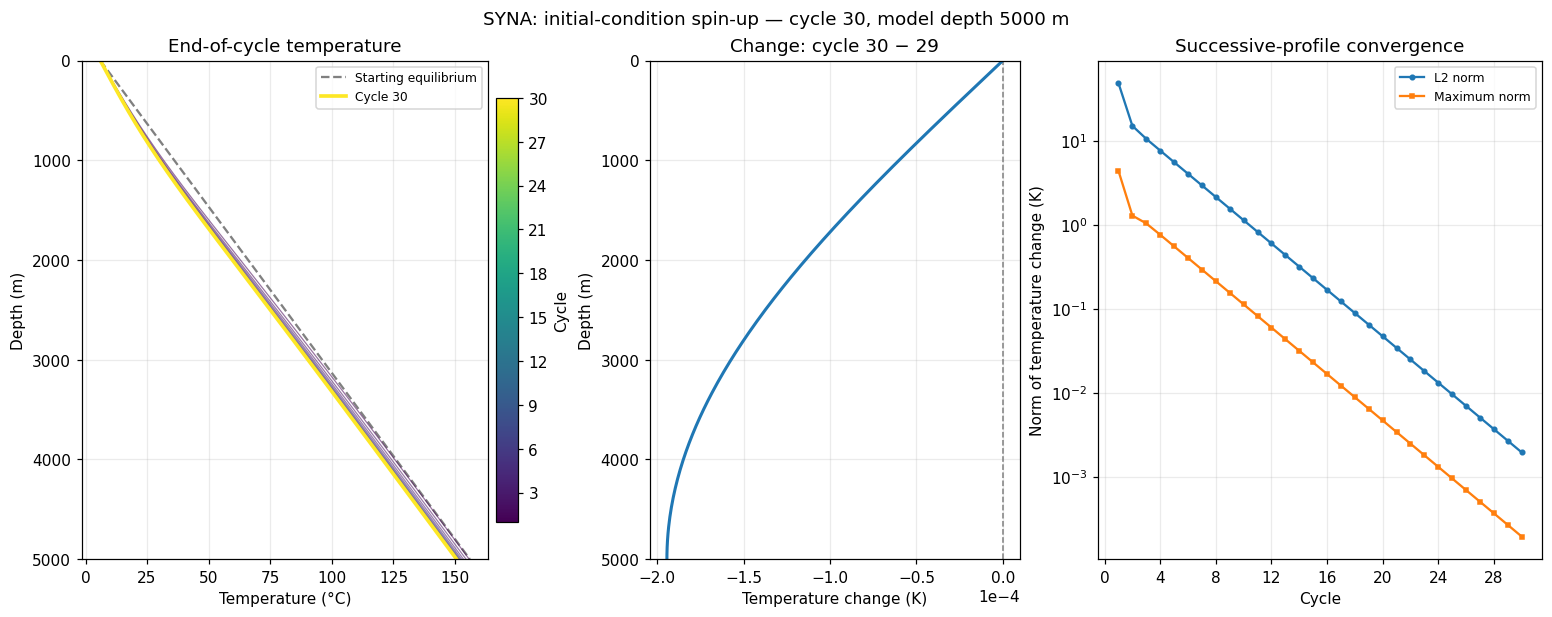

Initialisation completed: periodic, 30 cycles
Last L2 change: 0.0019505841 K
Last maximum change: 0.00019432318 K
Convergence: fixed cycle count; no stopping tolerance requested
Saved 30 cycle plots.
Diagnostics: C:\Users\Mottaghy\Documents\GitHub\PyBTI\examples\A\output\notebook\periodic\cycles\SYNA_Init_diagnostics.csv


In [7]:
cycle_display = None

def display_cycle(figure):
    """Refresh one notebook output after each completed initialisation cycle."""
    global cycle_display
    if cycle_display is None:
        cycle_display = display(figure, display_id=True)
    else:
        cycle_display.update(figure)

initial_settings = dict(initpar, GST=forcing["GST"], it=forcing["it"])
if initpar["init_type"] == "periodic":
    initial_settings["plotpar"] = dict(
        outdir=OUTPUT / "cycles", show=False, dpi=120,
        display_callback=display_cycle,
    )
initial = build_initial(sitepar, fwdpar, initial_settings)
print(f"Initialisation completed: {initial['init_type']}, {initial['niter']} cycles")
if initial["niter"]:
    print(f"Last L2 change: {initial['change_l2'][-1]:.8g} K")
    print(f"Last maximum change: {initial['changes'][-1]:.8g} K")
    print("Convergence:", "fixed cycle count; no stopping tolerance requested"
          if initial["converged"] is None else initial["converged"])
    print(f"Saved {len(initial['plot_files'])} cycle plots.")
    print(f"Diagnostics: {initial['monitor_plot']['diagnostics_file']}")


## 7. Inspect the resulting initial profile
`initial["Tinit"]` is the profile to pass to a subsequent model.
`Tsteady` retains the starting equilibrium; `Tit[:, j]` retains each completed
cycle's final profile. The following figure always shows the entire model depth.


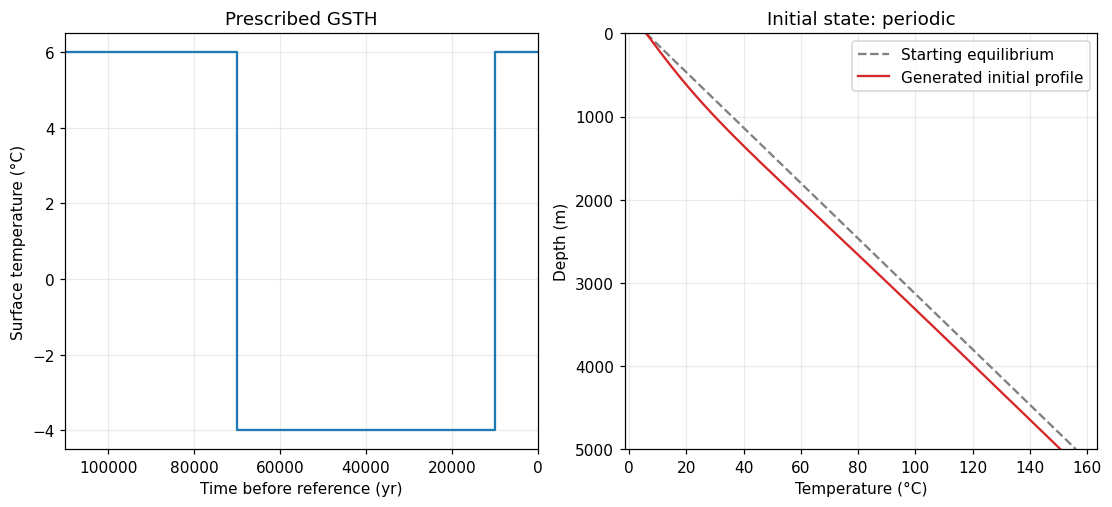

Cycle      L2 change [K]      Maximum change [K]
    1          48.295532               4.3621124
    2          14.972913               1.2820113
    3          10.500941               1.0342551
    4          7.6207388              0.75850052
    5          5.5432726              0.55219639
    6          4.0328808              0.40176554
    7          2.9340738              0.29230132
    8          2.1346527              0.21266065
    9          1.5530429              0.15471891
   10          1.1298992              0.11256403
   11         0.82204565             0.081894713
   12         0.59807023             0.059581593
   13         0.43511938             0.043347929
   14          0.3165663             0.031537307
   15         0.23031431             0.022944619
   16         0.16756264             0.016693104
   17         0.12190834             0.012144883
   18        0.088693069            0.0088358758
   19        0.064527663            0.0064284438
   20        0.04694

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
axes[0].step(age, np.r_[applied_gst, applied_gst[-1]], where="post")
axes[0].set(xlabel="Time before reference (yr)", ylabel="Surface temperature (°C)",
            title="Prescribed GSTH", xlim=(age[0], age[-1]))
axes[1].plot(initial["Tsteady"], initial["zinit"], "--", color="0.5",
             label="Starting equilibrium")
axes[1].plot(initial["Tinit"], initial["zinit"], color="tab:red",
             label="Generated initial profile")
axes[1].set(xlabel="Temperature (°C)", ylabel="Depth (m)",
            title=f"Initial state: {initial['init_type']}",
            ylim=(mesh["z"][-1], 0))
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
OUTPUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT / "SYNA_initial_profile.png", dpi=150)
plt.show()

if initial["niter"]:
    print("Cycle      L2 change [K]      Maximum change [K]")
    for cycle, l2, maximum in zip(
        range(1, initial["niter"] + 1), initial["change_l2"], initial["changes"]
    ):
        print(f"{cycle:5d} {l2:18.8g} {maximum:23.8g}")


## 8. Optional separate forward simulation
With equilibrium initialisation, this applies the prescribed GST history once.
After periodic initialisation it is **skipped by default**; set
`forward_options["run_after_periodic"] = True` in step 1 to deliberately run an
additional history.

Only this separate forward/data-comparison step uses observed-minus-calculated
residuals. Those residuals do not measure initialisation convergence.


In [9]:
run_separate_forward = (
    initial["init_type"] == "equilibrium" or forward_options["run_after_periodic"]
)
result = None
run = dict(name=sitepar["name"], mesh=mesh, site=sitepar,
           fwd=fwdpar, init=initial, result=None)
if run_separate_forward:
    result = run_forward(sitepar, fwdpar, initial)
    run["result"] = result
    forward_plot = plot_forward(
        run, dict(outdir=OUTPUT / "forward", show=False,
                  show_residuals=forward_options["show_residuals"])
    )
    display(forward_plot["figure"])
    plt.close(forward_plot["figure"])
    print("Separate forward simulation completed.")
else:
    print("Periodic initialisation only: no extra forward simulation was run.")


Periodic initialisation only: no extra forward simulation was run.


## 9. Save reusable numerical results and the input settings
The NPZ file stores arrays without Python objects, and can be loaded with
`np.load(path, allow_pickle=False)`. The JSON file records the parameter
dictionaries, units, and package versions. Output folders are separated by
initialisation mode; rerunning a mode replaces files with the same names.
If you reduce the cycle count, older PNGs may remain; use
`initial["plot_files"]` for the current run's exact list.


In [10]:
arrays = dict(
    z=mesh["z"], t=mesh["t"], GST=initial["GST"], it=initial["it"],
    Tsteady=initial["Tsteady"], Tinit=initial["Tinit"], Tit=initial["Tit"],
    change_l2=initial["change_l2"], changes=initial["changes"],
)
if result is not None:
    arrays["Tcalc"] = result["Tcalc"]
archive = OUTPUT / "SYNA_workflow.npz"
np.savez_compressed(archive, **arrays)

def json_value(value):
    """Convert paths and NumPy values for a readable parameter record."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Cannot serialise {type(value).__name__}")

record = dict(
    datapar=datapar, meshpar=mesh_settings, sitepar=site_inputs,
    fwdpar=fwdpar, gstpar=gstpar, initpar=initpar,
    forward_options=forward_options,
    units=dict(depth="m", time="s relative to reference",
               temperature="deg C", profile_change="K", heat_flow="W/m2"),
    versions=dict(python=platform.python_version(), numpy=np.__version__,
                  scipy=scipy.__version__, matplotlib=matplotlib.__version__),
    completed_cycles=initial["niter"], converged=initial["converged"],
    forward_run=result is not None, cycle_plot_files=initial["plot_files"],
)
settings_file = OUTPUT / "SYNA_parameters.json"
settings_file.write_text(json.dumps(record, indent=2, default=json_value),
                         encoding="utf-8")
with np.load(archive, allow_pickle=False) as saved:
    np.testing.assert_array_equal(saved["Tinit"], initial["Tinit"])
print(f"Saved and checked: {archive}")
print(f"Parameter record: {settings_file}")


Saved and checked: C:\Users\Mottaghy\Documents\GitHub\PyBTI\examples\A\output\notebook\periodic\SYNA_workflow.npz
Parameter record: C:\Users\Mottaghy\Documents\GitHub\PyBTI\examples\A\output\notebook\periodic\SYNA_parameters.json


## 10. Configure Tikhonov inversion — SITE_Tikh.m
This now runs after initialisation. The initial profile `Tinit`, material
properties and basal heat flow are **fixed** during each inversion. The unknowns
are 21 piecewise-constant GST parameters. Initialisation's full time-node GST
mapping and the coarser inversion mapping are separate.

The settings below come from `templates/SITE_Tikh.m`: a logarithmic grid from
110,000 to 30 years, prior and starting parameter values of 1, finite-difference
step 0.001 K, five warm-up updates, and 48 first-difference regularisation
weights from 10⁻³ to 10³. The synthetic site's `gts=0` makes the parameter
values absolute °C. For nonzero `gts`, the solver uses `GST = m + gts`.

The template's OKU site name, material model, GST file and basal heat-flow sweep
are not applied to synthetic A. Its heat-flow experiment is available in step 14.
The known GSTH is displayed for comparison and used for the chosen initialisation;
it is **not** copied into the inversion prior.

Implementation details that affect interpretation:
- Observation residuals and Jacobian are both weighted by `1 / Terr`.
- `regpar0` supplies warm-up weights. `regbase=(1,1,1)` preserves all three
  candidate columns; it does not mask the first-difference search.
- `tol_inv` follows the existing solver's order: RMS target, then minimum RMS
  improvement (the MATLAB template comment describes the opposite order).
- Full updates implement the template's `relax=1`; unused relaxation-scheduler
  fields are not passed. Only FD sensitivities are implemented.
- Convergence checks wait until a requested GCV search has occurred.
  `maxiter_inv` counts evaluated models, including the starting guess.
- Regularisation penalises differences between GST parameter values; it does
  not divide by the unequal time-bin lengths, matching the translated operators.


In [11]:
from workflow import build_inversion, run_inversion, plot_inversion

invgridpar = dict(
    nsteps=21, base=0.0, tstart=110000 * YEAR2SEC, tend=30 * YEAR2SEC, gmode="log",
)
inv_settings = dict(
    m_apr_set=1.0, m_ini_set=1.0,
    diffmeth="FD", dp=0.001,
    tol_solve=1e-5, maxiter_solve=32,
    tol_inv=(1e-4, 1e-5), maxiter_inv=100,
    reg_opt="GCV", start_regpar=5, modul_regpar=1,
    regpar0=(1.0, 0.0, 0.0), regbase=(1.0, 1.0, 1.0),
    reg0par=[0.01], reg1par=np.logspace(-3.0, 3.0, 48), reg2par=[0.0],
    reg_shift=0, outsteps=False, seed=0,
)
invpar = build_inversion(mesh, invgridpar, inv_settings)
INV_OUTPUT = OUTPUT / "tikhonov"
invrunpar = dict(outdir=INV_OUTPUT, name="SYNA_GCV", verbose=True, n_jobs=1)

# None uses only the synthetic site's specified basal heat flow.
# Optional SITE_Tikh.m experiment:
# heatflow_experiment["qb_values"] = [-36e-3, -38e-3, -40e-3, -42e-3, -44e-3]
heatflow_experiment = dict(qb_values=None)

print(f"Inversion: {invpar['nsteps']} GST parameters; "
      f"{len(sitepar['Tobs'])} observations; qb={sitepar['qb']*1000:.3f} mW/m²")
print("Integration intervals per parameter:",
      np.bincount(invpar["it"][:-1], minlength=invpar["nsteps"]))
print(f"GCV candidates: {len(inv_settings['reg1par'])}")
if np.any(sitepar["Tcov"] - np.diag(np.diag(sitepar["Tcov"]))):
    raise ValueError("Tikhonov currently requires diagonal Tcov. "
                     "Disable correlated synthetic noise or use independent noise.")


Inversion: 21 GST parameters; 40 observations; qb=-69.759 mW/m²
Integration intervals per parameter: [20 21 20 20 20 21 20 20 20 20 20 20 20 20 20 20 20 20 20 19  1]
GCV candidates: 48


## 11. Run the inversion
The objective combines squared, uncertainty-weighted temperature residuals with
zeroth-, first- and second-difference penalties relative to the prior. GCV selects
the regularisation candidate during each scheduled search.

The printed RMS is **dimensionless**. A separate unweighted RMSE in K is reported
below. These are inversion/data-fit diagnostics, unlike the successive-profile
norms used to check periodic initialisation.

Recovering the known history exactly is not guaranteed: the inverse problem is
ill-conditioned, the synthetic file was generated separately, and the inversion
is conditional on the selected initial profile and fixed basal heat flow.


In [12]:
inversion = run_inversion(sitepar, fwdpar, invpar, initial, invrunpar)
residual = sitepar["Tobs"] - inversion["Tcalc"][sitepar["id"], -1]
np.testing.assert_allclose(inversion["r_iter"][-1], residual)
np.testing.assert_array_equal(inversion["m"], inversion["m_iter"][-1])
print(f"Stop reason: {inversion['stop_reason']}; "
      f"evaluated models: {inversion['niter']}")
print(f"Weighted RMS: {inversion['rms_iter'][0]:.6g} → "
      f"{inversion['rms_iter'][-1]:.6g}")
print(f"Temperature RMSE: {np.sqrt(np.mean(residual**2)):.6g} K")
print("Final weights (tau0, tau1, tau2):", inversion["regpar"])

search = inversion["search"]
if search:
    selected = search["selected_index"]
    candidate = search["regpar"][selected]
    for j in range(3):
        values = np.unique(search["regpar"][:, j])
        if values.size > 1 and candidate[j] in (values[0], values[-1]):
            print(f"GCV selected a boundary of the tau{j} search range "
                  f"({candidate[j]:.6g}); consider extending that range "
                  "before interpreting it as an interior optimum.")
else:
    print("No GCV search was completed; check maxiter_inv and start_regpar.")


Nonlinear Tikhonov GSTH Inversion (Single Site): SYNA_GCV
 ...... no of parameters   = 21
 ...... no of observations = 40
 ...... iteration 0  rms= 42.6689  mae= 37.4096   (SYNA_GCV)


 ...... iteration 1  rms= 2.09488  mae= 1.46598   (SYNA_GCV)
 ... theta = 862.691  theta_d = 175.541  theta_m = 687.15  tau = (    1     0     0)


 ...... iteration 2  rms= 2.09491  mae= 1.46598   (SYNA_GCV)
 ... theta = 862.691  theta_d = 175.545  theta_m = 687.146  tau = (    1     0     0)


 ...... iteration 3  rms= 2.09494  mae= 1.46595   (SYNA_GCV)
 ... theta = 862.691  theta_d = 175.55  theta_m = 687.141  tau = (    1     0     0)


 ...... iteration 4  rms= 2.09493  mae= 1.46596   (SYNA_GCV)
 ... theta = 862.691  theta_d = 175.549  theta_m = 687.142  tau = (    1     0     0)


...

 min(GCV) = 0.0935071 at index: 1  RegPar = [0.01  0.001 0.   ]


 ...... iteration 6  rms= 0.235074  mae= 0.153751   (SYNA_GCV)
 ... theta = 18.3583  theta_d = 2.21039  theta_m = 16.1479  tau = ( 0.01 0.001     0)


 min(GCV) = 0.0935029 at index: 1  RegPar = [0.01  0.001 0.   ]


 ...... iteration 7  rms= 0.235069  mae= 0.153821   (SYNA_GCV)
 ... theta = 18.3583  theta_d = 2.2103  theta_m = 16.148  tau = ( 0.01 0.001     0)


Stop reason: rms_stagnation; evaluated models: 8
Weighted RMS: 42.6689 → 0.235069
Temperature RMSE: 0.0117534 K
Final weights (tau0, tau1, tau2): [0.01  0.001 0.   ]
GCV selected a boundary of the tau1 search range (0.001); consider extending that range before interpreting it as an interior optimum.


## 12. Plot results — SITE_TikhPlot.m
The main template panels are recovered GSTH, observed-minus-calculated
temperature residuals, and conductivity × temperature gradient. Temperature-fit,
iteration-RMS and GCV panels are added to make the inversion inspectable.

Corrections to the plotting template:
- Use age before the model reference; omit the arbitrary 13.5-year shift.
- A symmetric-log age axis includes the present, with a 10-year linear region.
- Label apparent upward heat flow in **mW/m²**, not K/km.
- Use effective conductivity from the final model. Between sparse data depths,
  use a thickness-weighted harmonic conductivity over all intervening cells.
- Smooth only data-derived heat flow with the template's 21-point mirrored
  boxcar; temperature observations and residuals remain unsmoothed.
- No site-specific depth/temperature clipping is imposed.
- `Cmm` is a local inverse regularised Hessian conditional on the fixed setup;
  it is not displayed as a complete posterior uncertainty band.

For the default periodic synthetic A run, the recovered history is oscillatory
despite a small temperature residual, and GCV chooses the smallest tested tau1.
This is a data-fit result, not evidence of unique or accurate paleoclimate
recovery. The displayed known history makes the mismatch visible; the template
search range is retained rather than silently tuned to that history.


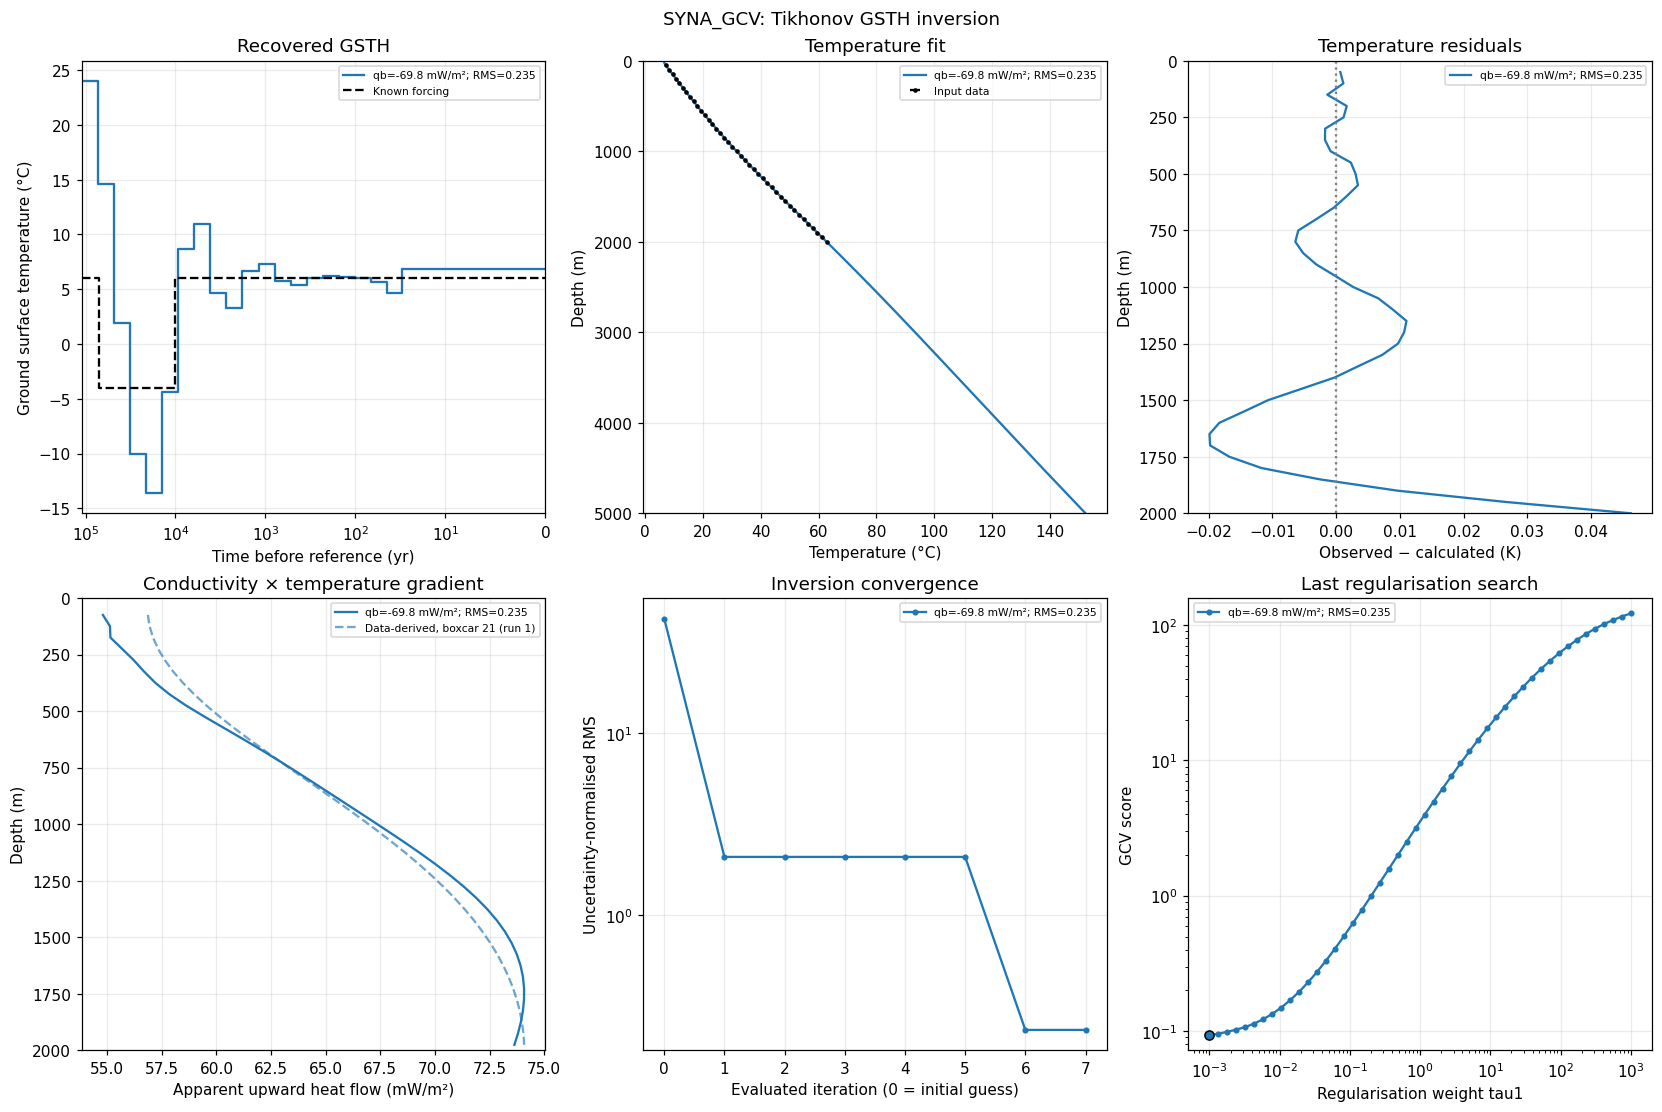

Saved figures:
examples\A\output\notebook\periodic\tikhonov\SYNA_GCV_Tikh.png
examples\A\output\notebook\periodic\tikhonov\SYNA_GCV_Tikh.pdf


In [13]:
tikh_plotpar = dict(
    name="SYNA_GCV", outdir=INV_OUTPUT, formats=("png", "pdf"),
    show=False, time_scale="symlog", smooth_window=21,
    reference=dict(t=mesh["t"], GST=forcing["GST"], it=forcing["it"]),
)
inversion_plot = plot_inversion(inversion, tikh_plotpar)
display(inversion_plot["figure"])
plt.close(inversion_plot["figure"])
print("Saved figures:")
for path in inversion_plot["filenames"]:
    print(path)


## 13. Save inversion settings, history and the recovered GST grid
The driver saves numerical result arrays plus the actual starting and prior
parameter vectors. The following files additionally record the complete settings,
stopping reason, last GCV search and readable iteration/GST tables.

`m_iter[j]`, `r_iter[j]`, `rms_iter[j]` and `regpar_iter[j]` all refer to the
same evaluated model. Saved final temperatures and the final Jacobian correspond
to the returned final `m`, including when the iteration limit is reached.


In [14]:
iteration_table = np.column_stack((
    np.arange(inversion["niter"]), inversion["rms_iter"],
    inversion["theta_d_iter"], inversion["theta_m_iter"],
    inversion["regpar_iter"],
))
np.savetxt(
    INV_OUTPUT / "SYNA_GCV_iterations.csv", iteration_table, delimiter=",",
    header="iteration,weighted_rms,theta_data,theta_model,tau0,tau1,tau2", comments="",
)
grid_rows = []
for j in range(invpar["nsteps"]):
    intervals = np.flatnonzero(invpar["it"][:-1] == j)
    grid_rows.append((
        j, -mesh["t"][intervals[0]] / YEAR2SEC,
        -mesh["t"][intervals[-1] + 1] / YEAR2SEC,
        inversion["m"][j] + sitepar["gts"],
        inversion["m_apr"][j] + sitepar["gts"],
    ))
np.savetxt(
    INV_OUTPUT / "SYNA_GCV_GST.csv", grid_rows, delimiter=",",
    header="parameter,oldest_age_yr,youngest_age_yr,recovered_GST_degC,prior_GST_degC",
    comments="",
)
search_arrays = {key: value for key, value in inversion["search"].items()
                 if isinstance(value, np.ndarray)}
np.savez_compressed(INV_OUTPUT / "SYNA_GCV_search.npz", **search_arrays)
inverse_record = dict(
    source_templates=["templates/SITE_Tikh.m", "templates/SITE_TikhPlot.m"],
    invgridpar=invgridpar, invpar=invpar, runpar=invrunpar,
    sitepar=site_inputs, fwdpar=fwdpar, initpar=initpar,
    initialisation_cycles=initial["niter"], initial_state_fixed=True,
    weight_residual=True, heatflow_experiment=heatflow_experiment,
    stop_reason=inversion["stop_reason"], converged=inversion["converged"],
    selected_regpar=inversion["regpar"],
    weighted_rms=float(inversion["rms_iter"][-1]),
    temperature_rmse_K=float(np.sqrt(np.mean(residual**2))),
    versions=record["versions"],
)
(INV_OUTPUT / "SYNA_GCV_parameters.json").write_text(
    json.dumps(inverse_record, indent=2, default=json_value), encoding="utf-8"
)
print(f"Inversion outputs: {INV_OUTPUT}")
print("Results, starting/prior vectors, iteration CSV, recovered-GST CSV, "
      "GCV search and parameter JSON saved.")


Inversion outputs: C:\Users\Mottaghy\Documents\GitHub\PyBTI\examples\A\output\notebook\periodic\tikhonov
Results, starting/prior vectors, iteration CSV, recovered-GST CSV, GCV search and parameter JSON saved.


## 14. Optional basal heat-flow experiment
To reproduce the **structure** of the template's heat-flow sweep, set
`heatflow_experiment["qb_values"]` in step 10 to a list of signed W/m² values.
The commented values are the original OKU experiment, not values inferred for A.

For each value, rebuild the steady/periodic initial condition using that basal
heat flow, then invert with the same GST grid and controls. Each case writes to
its own folder. The combined figure accepts an explicit list of results rather
than loading every result file in the working directory.


In [15]:
sweep_results = []
for qb in heatflow_experiment["qb_values"] or []:
    if not np.isfinite(qb):
        raise ValueError("Each basal heat-flow value must be finite.")
    case_name = f"SYNA_qb_{qb*1000:+.3f}_mWm2"
    case_site = dict(sitepar, qb=float(qb), name=case_name)
    case_initial = build_initial(
        case_site, fwdpar, dict(initpar, GST=forcing["GST"], it=forcing["it"])
    )
    case_result = run_inversion(
        case_site, fwdpar, invpar, case_initial,
        dict(invrunpar, name=case_name, outdir=INV_OUTPUT / case_name)
    )
    sweep_results.append(case_result)

if sweep_results:
    comparison = plot_inversion(
        [inversion, *sweep_results],
        dict(tikh_plotpar, name="SYNA_Qb_comparison")
    )
    display(comparison["figure"])
    plt.close(comparison["figure"])
else:
    print("Basal heat-flow sweep disabled; the synthetic site's qb was used.")


Basal heat-flow sweep disabled; the synthetic site's qb was used.


## 15. Switching to measured data
Change the data file, column mapping, depth range and uncertainty specification;
set `synthetic=False` and omit artificial noise. Update material properties,
basal heat flow, prescribed initialisation history and inversion prior explicitly.
Retain a numerical depth of at least 5,000 m and extend it if needed.

The current Tikhonov adapter requires diagonal observational covariance. A
correlated-noise inversion needs a whitening implementation before it can be run.
The known synthetic forcing overlay should be removed for real data unless an
independent comparison history is available. MCMC and SITE_Plot remain deferred.
